# Berkshire Hathaway (BRK-B) — Total Returns Analysis

In [2]:
import yfinance as yf
import pandas as pd

# Download 10 years of daily data for BRK-B
# auto_adjust=True folds splits/dividends into the price so pct_change gives total return
ticker = yf.Ticker("BRK-B")
raw = ticker.history(period="10y", interval="1d", auto_adjust=True)

# Daily total returns
daily_returns = raw["Close"].pct_change().dropna()
daily_returns.name = "daily_return"

print(f"Date range: {daily_returns.index[0].date()} to {daily_returns.index[-1].date()}")
print(f"Trading days: {len(daily_returns)}")
daily_returns.head()

Date range: 2016-03-18 to 2026-03-16
Trading days: 2512


Date
2016-03-18 00:00:00-04:00   -0.001685
2016-03-21 00:00:00-04:00   -0.000211
2016-03-22 00:00:00-04:00    0.000352
2016-03-23 00:00:00-04:00   -0.008581
2016-03-24 00:00:00-04:00   -0.006030
Name: daily_return, dtype: float64

In [3]:
# Aggregate daily total returns to monthly by compounding
# (1 + r1) * (1 + r2) * ... - 1
monthly_returns = (
    (1 + daily_returns)
    .resample("ME")           # month-end frequency
    .prod()
    - 1
)
monthly_returns.name = "monthly_return"
monthly_returns.index = monthly_returns.index.to_period("M")

print(f"Months: {len(monthly_returns)}")
monthly_returns

Months: 121


/tmp/ipykernel_6413/2393026939.py:10: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_returns.index = monthly_returns.index.to_period("M")


Date
2016-03   -0.003652
2016-04    0.025373
2016-05   -0.033957
2016-06    0.030241
2016-07   -0.003591
             ...   
2025-11    0.075952
2025-12   -0.021720
2026-01   -0.044007
2026-02    0.050819
2026-03   -0.025230
Freq: M, Name: monthly_return, Length: 121, dtype: float64

In [4]:
# Descriptive statistics on monthly returns
desc = monthly_returns.describe()
desc.loc["annualized_mean"] = (1 + monthly_returns.mean()) ** 12 - 1
desc.loc["annualized_vol"]  = monthly_returns.std() * (12 ** 0.5)
desc.loc["skewness"]        = monthly_returns.skew()
desc.loc["kurtosis"]        = monthly_returns.kurt()
desc.loc["positive_months"] = (monthly_returns > 0).mean()

print(desc.to_string())


count              121.000000
mean                 0.011622
std                  0.051745
min                 -0.135958
25%                 -0.027485
50%                  0.011764
75%                  0.051550
max                  0.133779
annualized_mean      0.148738
annualized_vol       0.179252
skewness            -0.073866
kurtosis            -0.324395
positive_months      0.553719


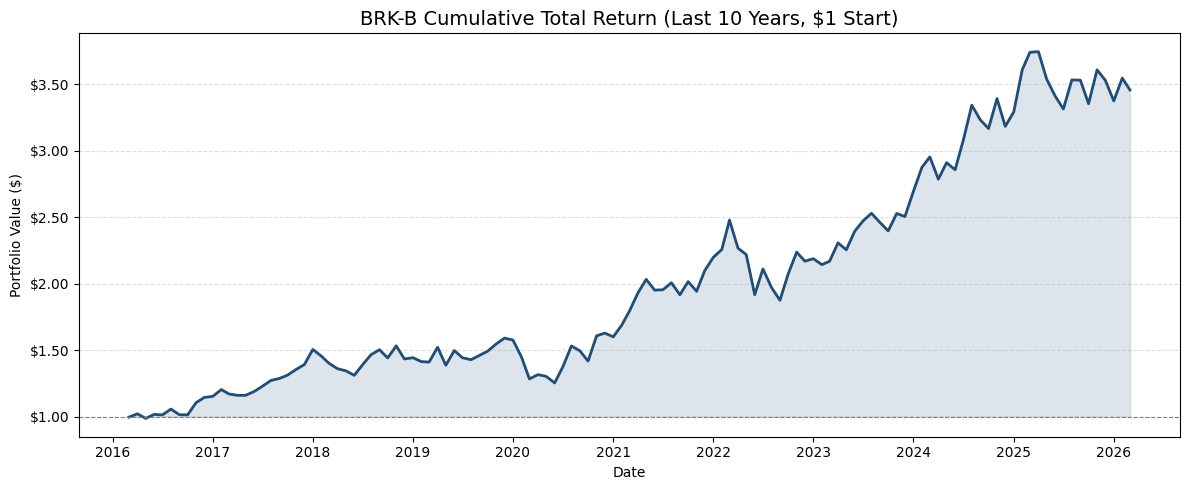

$1 invested 10 years ago is now worth $3.46


In [6]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

cumulative = (1 + monthly_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(cumulative.index.to_timestamp(), cumulative.values, linewidth=2, color="#1f4e79")
ax.fill_between(cumulative.index.to_timestamp(), 1, cumulative.values,
                alpha=0.15, color="#1f4e79")
ax.axhline(1, color="gray", linewidth=0.8, linestyle="--")

ax.set_title("BRK-B Cumulative Total Return (Last 10 Years, $1 Start)", fontsize=14)
ax.set_xlabel("Date")
ax.set_ylabel("Portfolio Value ($)")
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("$%.2f"))
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

final = cumulative.iloc[-1]
print(f"$1 invested 10 years ago is now worth ${final:.2f}")


In [8]:
import io
import zipfile
import requests

FF3_URL = "https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/F-F_Research_Data_Factors_CSV.zip"

resp = requests.get(FF3_URL)
resp.raise_for_status()

with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
    fname = z.namelist()[0]
    raw_text = z.read(fname).decode("utf-8")

# Row 5 (0-indexed: row 4) has the headers: blank, Mkt-RF, SMB, HML, RF
ff3 = pd.read_csv(
    io.StringIO(raw_text),
    skiprows=4,
    index_col=0,
    on_bad_lines="skip",
)
ff3.index.name = "date"
ff3.columns = ff3.columns.str.strip()

# Keep only rows where index is a 6-digit YYYYMM integer (monthly data)
ff3 = ff3[ff3.index.astype(str).str.match(r"^\s*\d{6}\s*$")]
ff3.index = pd.PeriodIndex(ff3.index.astype(str).str.strip(), freq="M")

# Convert from percent to decimal
ff3 = ff3.apply(pd.to_numeric, errors="coerce") / 100
ff3 = ff3.dropna()

print(f"FF3 date range: {ff3.index[0]} to {ff3.index[-1]}")
ff3.tail()


FF3 date range: 1926-07 to 2026-01


,Mkt-RF,SMB,HML,RF
date,,,,
2025-09,0.0339,-0.0185,-0.0105,0.0033
2025-10,0.0196,-0.0055,-0.0310,0.0037
2025-11,-0.0013,0.0038,0.0376,0.0030
2025-12,-0.0036,-0.0106,0.0242,0.0034
2026-01,0.0102,0.0221,0.0370,0.0030


In [9]:
# Descriptives on FF3 factors
ff3_desc = ff3.describe()
ff3_desc.loc["annualized_mean"] = (1 + ff3.mean()) ** 12 - 1
ff3_desc.loc["annualized_vol"]  = ff3.std() * (12 ** 0.5)
ff3_desc.loc["skewness"]        = ff3.skew()
ff3_desc.loc["kurtosis"]        = ff3.kurt()
ff3_desc.loc["positive_months"] = (ff3 > 0).mean()

ff3_desc.style.format("{:.4f}")


,Mkt-RF,SMB,HML,RF
count,1195.0000,1195.0000,1195.0000,1195.0000
mean,0.0069,0.0017,0.0035,0.0027
std,0.0531,0.0315,0.0355,0.0025
min,-0.2874,-0.1741,-0.1383,-0.0006
25%,-0.0200,-0.0163,-0.0143,0.0003
50%,0.0108,0.0006,0.0014,0.0023
75%,0.0365,0.0173,0.0176,0.0042
max,0.3881,0.3596,0.3552,0.0135
annualized_mean,0.0863,0.0201,0.0428,0.0329
annualized_vol,0.1838,0.1092,0.1231,0.0086
